# Performance Analytics (Polished)
\n
This notebook provides EDA, distribution validation, extended alpha/beta checks, tracking-error export, and visualizations using the analysis outputs.

In [1]:
# Setup & imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown
sns.set(style='whitegrid')
%matplotlib inline
RISK_FREE = 0.065

In [2]:
# Reproducibility
import random
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
display(Markdown('**Seed:** {}  **Risk-free used:** {}'.format(SEED, RISK_FREE)))

**Seed:** 42  **Risk-free used:** 0.065

In [3]:
# Load files
base = os.path.abspath('..')
score_fp = os.path.join(base, 'fund_scorecard.csv')
alpha_fp = os.path.join(base, 'alpha_beta.csv')
nav_fp = os.path.join(base, 'data','processed','cleaned_02_nav_history.csv')
bench_fp = os.path.join(base, 'data','processed','cleaned_10_benchmark_indices.csv')
score = pd.read_csv(score_fp)
alpha = pd.read_csv(alpha_fp)
nav = pd.read_csv(nav_fp, parse_dates=['date'])
bench = pd.read_csv(bench_fp, parse_dates=['date'])
display(score.shape)
display(alpha.shape)

(40, 35)

(40, 6)

In [4]:
# Sanity checks
display(score.head())
display(score.dtypes)
display(score.isna().sum())
nav2 = nav[nav['is_forward_filled']==0].copy()
display(nav2.groupby('amfi_code')['date'].agg(['min','max','count']).head())

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,...,r_value,p_value,stderr,rank_cagr_3yr,rank_sharpe,rank_alpha,rank_expense_inv,rank_mdd_inv,fund_score,fund_score_rank
0,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,...,NaN,NaN,NaN,35.0,35.0,NaN,-32.0,-7.0,29.7500,38.0
1,100025,HDFC Mutual Fund,HDFC Short Term Debt Fund - Regular - Growth,Debt,Short Duration,Regular,2002-06-25,CRISIL Short Term Bond Index,0.56,0.5,...,NaN,NaN,NaN,34.0,39.0,NaN,-2.0,-37.0,31.7500,36.0
2,100033,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,Regular,2007-06-25,NIFTY Midcap 150 TRI,1.38,1.0,...,NaN,NaN,NaN,4.0,7.0,NaN,-16.0,-21.0,72.6250,3.0
3,101206,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.60,1.0,...,NaN,NaN,NaN,9.0,9.0,NaN,-36.0,-32.0,57.5625,15.0
4,101207,Aditya Birla Sun Life MF,ABSL Small Cap Fund - Regular - Growth,Equity,Small Cap,Regular,2007-05-31,BSE 250 SmallCap TRI,1.53,1.0,...,NaN,NaN,NaN,39.0,28.0,NaN,-28.0,-3.0,33.4375,34.0


amfi_code               int64
fund_house                str
scheme_name               str
category                  str
sub_category              str
plan                      str
launch_date               str
benchmark                 str
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager              str
risk_category             str
sebi_category_code    float64
cagr_1yr              float64
cagr_3yr              float64
cagr_5yr              float64
sharpe                float64
sortino               float64
max_drawdown          float64
mdd_start                 str
mdd_end                   str
alpha                 float64
beta                  float64
r_value               float64
p_value               float64
stderr                float64
rank_cagr_3yr         float64
rank_sharpe           float64
rank_alpha            float64
rank_expense_inv      float64
rank_mdd_inv          float64
fund_score

amfi_code              0
fund_house             0
scheme_name            0
category               0
sub_category           0
plan                   0
launch_date            0
benchmark              0
expense_ratio_pct      0
exit_load_pct          0
min_sip_amount         0
min_lumpsum_amount     0
fund_manager           0
risk_category          0
sebi_category_code    40
cagr_1yr               0
cagr_3yr               0
cagr_5yr              40
sharpe                 0
sortino                0
max_drawdown           0
mdd_start              0
mdd_end                0
alpha                 40
beta                  40
r_value               40
p_value               40
stderr                40
rank_cagr_3yr          0
rank_sharpe            0
rank_alpha            40
rank_expense_inv       0
rank_mdd_inv           0
fund_score             0
fund_score_rank        0
dtype: int64

,min,max,count
amfi_code,,,
100016,2022-01-03,2026-05-29,1150
100025,2022-01-03,2026-05-29,1150
100033,2022-01-03,2026-05-29,1150
101206,2022-01-03,2026-05-29,1150
101207,2022-01-03,2026-05-29,1150


In [5]:
# Compute returns panel
nav2['daily_return'] = nav2.groupby('amfi_code')['nav'].pct_change()
returns = nav2.pivot(index='date', columns='amfi_code', values='daily_return')
dist_summary = returns.describe().T[['count','mean','std','min','25%','50%','75%','max']]
display(dist_summary.sort_values('std', ascending=False).head(10))

,count,mean,std,min,25%,50%,75%,max
amfi_code,,,,,,,,
101207,1149.0,0.000424,0.016251,-0.051847,-0.010799,0.000182,0.011286,0.054851
118634,1149.0,0.000707,0.015901,-0.058102,-0.010206,0.000921,0.011475,0.059304
119598,1149.0,0.001201,0.015837,-0.045180,-0.009953,0.001250,0.011683,0.064713
119095,1149.0,0.000182,0.015790,-0.048367,-0.010515,0.000172,0.011215,0.043110
119599,1149.0,0.000201,0.015717,-0.045429,-0.010537,0.000339,0.010319,0.053320
149324,1149.0,0.001194,0.015648,-0.048870,-0.008741,0.000987,0.011440,0.048490
119094,1149.0,0.001027,0.012225,-0.040755,-0.006747,0.000613,0.009274,0.041591
120505,1149.0,0.001161,0.012152,-0.038418,-0.007237,0.000955,0.009359,0.040812
100033,1149.0,0.001080,0.011929,-0.044238,-0.006654,0.001086,0.008844,0.041954


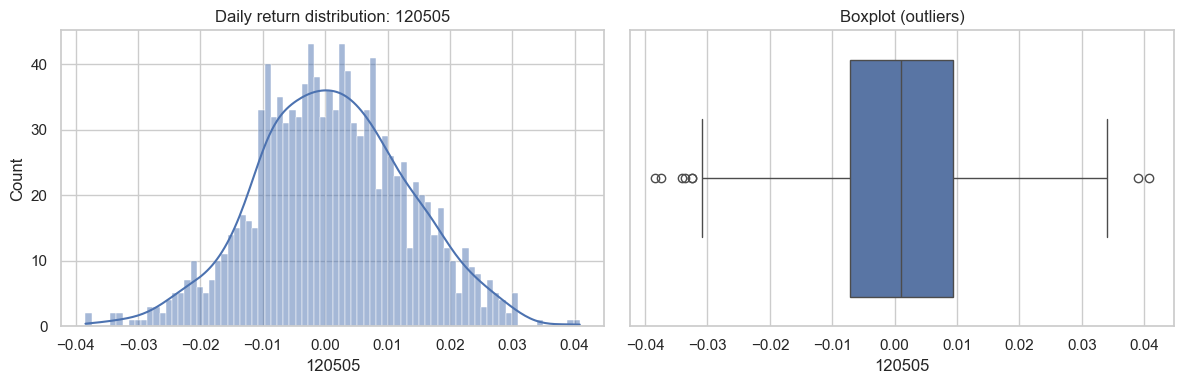

date
2024-12-31   -0.038418
2025-04-11   -0.037507
2022-07-20   -0.034085
2022-06-14   -0.033599
2025-07-07   -0.032517
2024-01-05   -0.032480
2023-03-27   -0.030914
2024-01-10   -0.030184
2023-03-17   -0.029405
2025-08-20   -0.027880
2025-04-09   -0.027640
2023-04-20   -0.027567
2025-07-21    0.028655
2024-09-04    0.028820
2023-09-25    0.029132
2023-05-03    0.029750
2023-12-01    0.029980
2025-04-03    0.030063
2026-05-04    0.030280
2022-01-05    0.030352
2022-10-14    0.030831
2022-07-28    0.033986
2026-04-08    0.039003
2022-07-26    0.040812
Name: 120505, dtype: float64

(24,)

In [6]:
# Distribution plot for a top fund
sample_code = int(score.sort_values('fund_score', ascending=False).iloc[0]['amfi_code'])
s = returns[sample_code].dropna()
import matplotlib.dates as mdates
fig, axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(s, bins=80, kde=True, ax=axes[0])
axes[0].set_title(f'Daily return distribution: {sample_code}')
sns.boxplot(x=s, ax=axes[1])
axes[1].set_title('Boxplot (outliers)')
plt.tight_layout()
plt.show()
# Outliers
extreme = s[(s < s.quantile(0.01)) | (s > s.quantile(0.99))]
display(extreme.sort_values())
display(extreme.shape)

In [7]:
# Recompute alpha/beta vs NIFTY 100 and NIFTY 50
from scipy import stats
bench_pivot = bench.pivot(index='date', columns='index_name', values='close_value')
bench_returns = bench_pivot.pct_change()
alpha_ext = []
for code in score['amfi_code'].unique():
    try:
        code_int = int(code)
    except:
        code_int = code
    fr = returns[code_int].dropna() if code_int in returns.columns else pd.Series(dtype=float)
    for b in ['NIFTY 100 TRI','NIFTY 50 TRI']:
        if b not in bench_returns.columns or fr.empty:
            alpha_ext.append({'amfi_code': code_int, 'benchmark': b, 'alpha': np.nan, 'beta': np.nan})
            continue
        merged = pd.concat([fr, bench_returns[b]], axis=1).dropna()
        if merged.empty:
            alpha_ext.append({'amfi_code': code_int, 'benchmark': b, 'alpha': np.nan, 'beta': np.nan})
            continue
        res = stats.linregress(merged.iloc[:,1].values, merged.iloc[:,0].values)
        alpha_a = res.intercept * 252
        beta_a = res.slope
        alpha_ext.append({'amfi_code': code_int, 'benchmark': b, 'alpha': alpha_a, 'beta': beta_a})
alpha_ext_df = pd.DataFrame(alpha_ext)
out_alpha_fp = os.path.join(base, 'alpha_beta_extended.csv')
alpha_ext_df.to_csv(out_alpha_fp, index=False)
display(alpha_ext_df.head())
display(Markdown(f'Wrote: {out_alpha_fp}'))

,amfi_code,benchmark,alpha,beta
0,100016,NIFTY 100 TRI,NaN,NaN
1,100016,NIFTY 50 TRI,NaN,NaN
2,100025,NIFTY 100 TRI,NaN,NaN
3,100025,NIFTY 50 TRI,NaN,NaN
4,100033,NIFTY 100 TRI,NaN,NaN


Wrote: c:\repos\cp1_Mutual_Fund_Analysis\alpha_beta_extended.csv

In [8]:
# Tracking error for top5 and save
top5 = score.sort_values('cagr_3yr', ascending=False).head(5)['amfi_code'].astype(int).tolist()
te_rows = []
for code in top5:
    if code not in returns.columns:
        continue
    fr = returns[code].dropna()
    for b in ['NIFTY 100 TRI','NIFTY 50 TRI']:
        if b not in bench_returns.columns:
            continue
        merged = pd.concat([fr, bench_returns[b]], axis=1).dropna()
        if merged.empty:
            continue
        diff = merged.iloc[:,0] - merged.iloc[:,1]
        te = diff.std() * np.sqrt(252)
        te_rows.append({'amfi_code': code, 'benchmark': b, 'tracking_error': te})
te_df = pd.DataFrame(te_rows)
out_te_fp = os.path.join(base, 'tracking_error_top5.csv')
te_df.to_csv(out_te_fp, index=False)
display(te_df)
display(Markdown(f'Wrote: {out_te_fp}'))

""


Wrote: c:\repos\cp1_Mutual_Fund_Analysis\tracking_error_top5.csv

C:\Users\ACER\AppData\Local\Temp\ipykernel_13324\1777913783.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cagr_3yr', y='scheme_name', data=top10, palette='viridis')


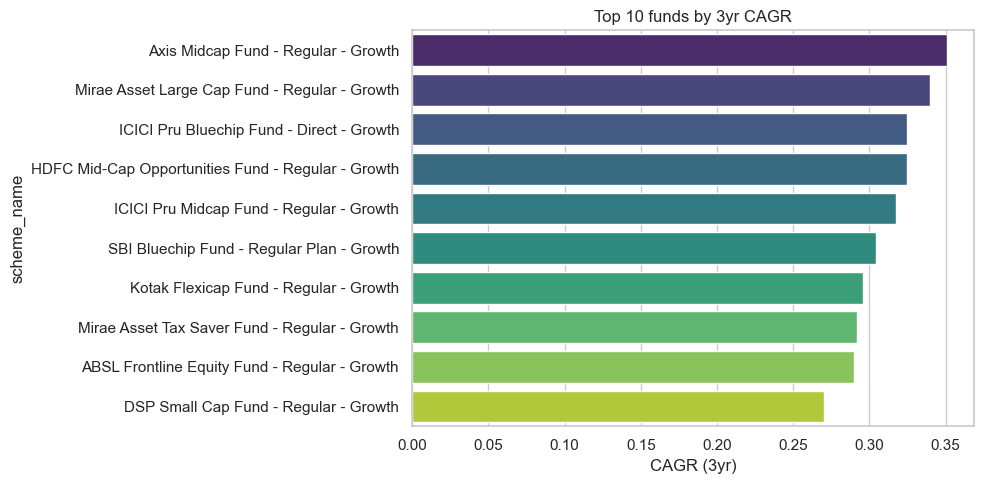

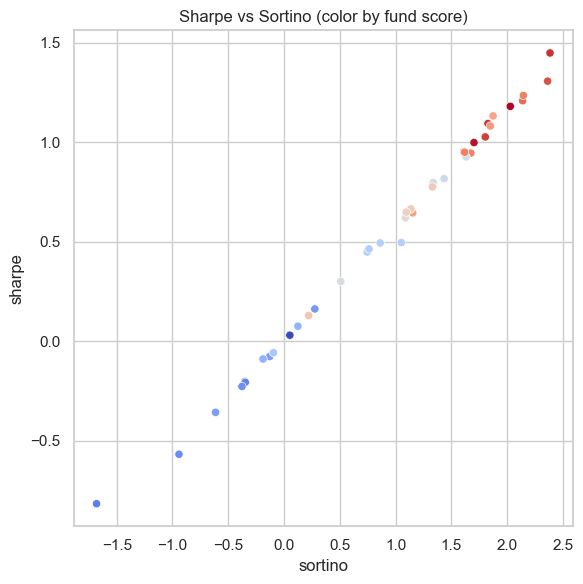

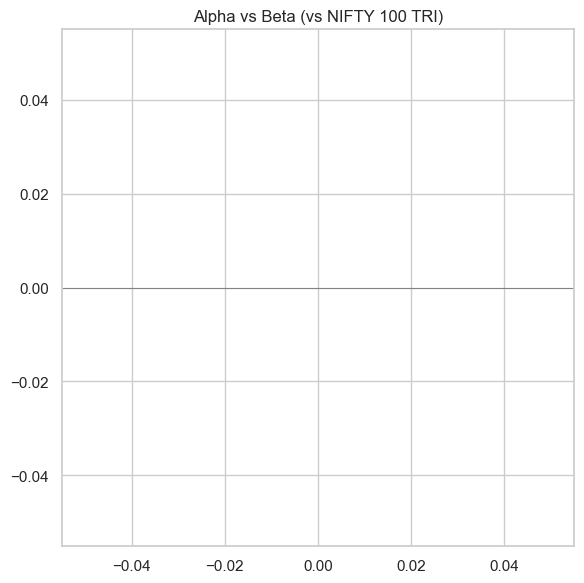

In [9]:
# Visualizations
import matplotlib.pyplot as plt
# CAGR bar for top 10 (3yr)
top10 = score.sort_values('cagr_3yr', ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x='cagr_3yr', y='scheme_name', data=top10, palette='viridis')
plt.title('Top 10 funds by 3yr CAGR')
plt.xlabel('CAGR (3yr)')
plt.tight_layout()
plt.show()
# Sharpe vs Sortino
plt.figure(figsize=(6,6))
sns.scatterplot(data=score, x='sortino', y='sharpe', hue='fund_score', palette='coolwarm', legend=False)
plt.title('Sharpe vs Sortino (color by fund score)')
plt.tight_layout()
plt.show()
# Alpha vs Beta (extended)
if 'alpha' in alpha_ext_df.columns:
    plt.figure(figsize=(6,6))
    sns.scatterplot(data=alpha_ext_df[alpha_ext_df['benchmark']=='NIFTY 100 TRI'], x='beta', y='alpha')
    plt.title('Alpha vs Beta (vs NIFTY 100 TRI)')
    plt.axhline(0, color='gray', linewidth=0.7)
    plt.tight_layout()
    plt.show()

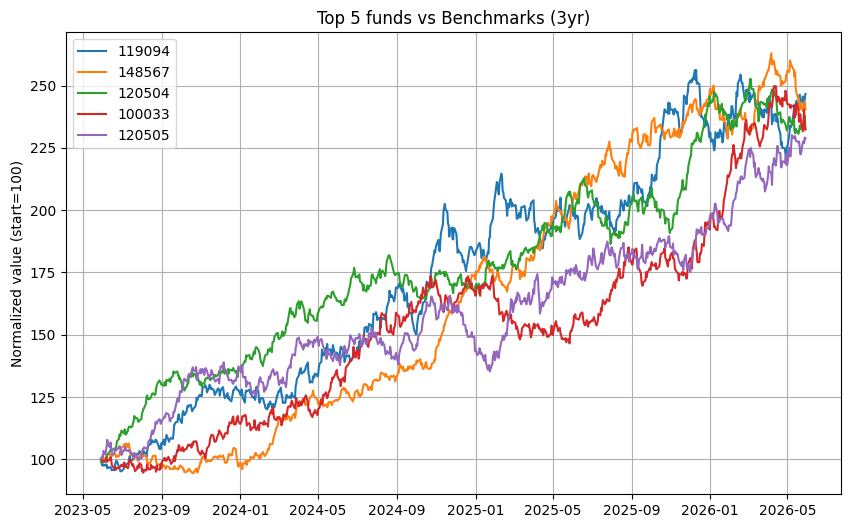

In [10]:
# Display benchmark comparison image if present
img_fp = os.path.join(base, 'benchmark_comparison.png')
if os.path.exists(img_fp):
    display(Image(filename=img_fp))
else:
    display(Markdown('No benchmark_comparison.png found in repo root'))

## Summary & next steps
- Added distribution checks and outlier listing for a sample fund.
- Saved `alpha_beta_extended.csv` and `tracking_error_top5.csv` to repository root.
- Recommended: review `fund_scorecard.csv` for any NaNs and re-run `scripts/performance_analysis.py` if you update data.

In [11]:
# Re-run helper
print('To regenerate outputs:')
print('python scripts/performance_analysis.py')

To regenerate outputs:
python scripts/performance_analysis.py
